In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('./data_cts_violent_and_sexual_crime.csv')

In [3]:
data.head(5)

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,AZE,Azerbaijan,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,155.0,CTS
1,BEL,Belgium,Europe,Western Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,61959.0,CTS
2,BGR,Bulgaria,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,3806.0,CTS
3,BHR,Bahrain,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,2701.0,CTS
4,BLR,Belarus,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,4032.0,CTS


In [4]:
WARS = (
    ("Ukraine",                  "Russian Federation",        2014, 2015, "Annessione Crimea"),
    ("Ukraine",                  "Russian Federation",        2022, 2024, "Invasione 2022"),
    ("Armenia",                  "Azerbaijan",                2020, 2020, "Nagorno-Karabakh 2020"),
    ("Armenia",                  "Azerbaijan",                2023, 2023, "Offensiva 2023"),
    ("Israel",                   "State of Palestine",        2008, 2009, "Operazione Gaza 2008"),
    ("Israel",                   "State of Palestine",        2014, 2014, "Operazione Gaza 2014"),
    ("Israel",                   "State of Palestine",        2023, 2024, "Offensiva Gaza 2023"),
    ("Russian Federation",       "Georgia",                   2008, 2008, "Guerra Ossezia del Sud"),
    ("United States of America", "Iraq (Central Iraq)",       2003, 2011, "Guerra Iraq"),
)

In [5]:
YR_MIN = int(data['Year'].min())
YR_MAX = int(data['Year'].max())

In [6]:
def plot_conflict(data, country1, country2):

    #Per ogni indicatore, traccia le serie storiche su tutti gli anni del dataset con i periodi di conflitto evidenziati in grigio.
    indicators = data['Indicator'].unique()
    countries  = [(country1, '#2166ac'), (country2, '#d6604d')]

    pair = {country1, country2}
    conflicts = [(s, e, label) for c1, c2, s, e, label in WARS if {c1, c2} == pair]

    fig, axes = plt.subplots(len(indicators), 1, figsize=(13, 5 * len(indicators)))
    if len(indicators) == 1:
        axes = [axes]

    for ax, indicator in zip(axes, indicators):
        has_data = False

        for country, color in countries:
            filtered = data[
                (data['Country'] == country) &
                (data['Unit of measurement'] == 'Counts') &
                (data['Indicator'] == indicator)
            ].groupby('Year')['VALUE'].sum().reset_index()

            if not filtered.empty:
                ax.plot(filtered['Year'], filtered['VALUE'],
                        marker='o', ms=3, color=color, label=country)
                has_data = True

        if has_data:
            # Asse x su tutti gli anni del dataset
            ax.set_xlim(YR_MIN - 0.5, YR_MAX + 0.5)
            ax.set_xticks(range(YR_MIN, YR_MAX + 1))
            ax.tick_params(axis='x', labelsize=8, rotation=45)

            # Bande grigie per i conflitti
            for s, e, label in conflicts:
                ax.axvspan(s - 0.4, e + 0.4, alpha=0.15, color='gray')
                ax.text((s + e) / 2, ax.get_ylim()[1] * 0.96, label,
                        ha='center', va='top', fontsize=7,
                        color='#555', style='italic')

            ax.set_title(indicator, fontsize=11, loc='left')
            ax.set_xlabel('Anno')
            ax.set_ylabel('Numero di casi')
            ax.legend()
            ax.grid(True, alpha=0.3)
        else:
            ax.axis('off')
            ax.text(0.5, 0.5, f'No data available for "{indicator}"',
                    ha='center', va='center', fontsize=11, color='gray',
                    transform=ax.transAxes)

    plt.suptitle(f'{country1}  vs  {country2}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

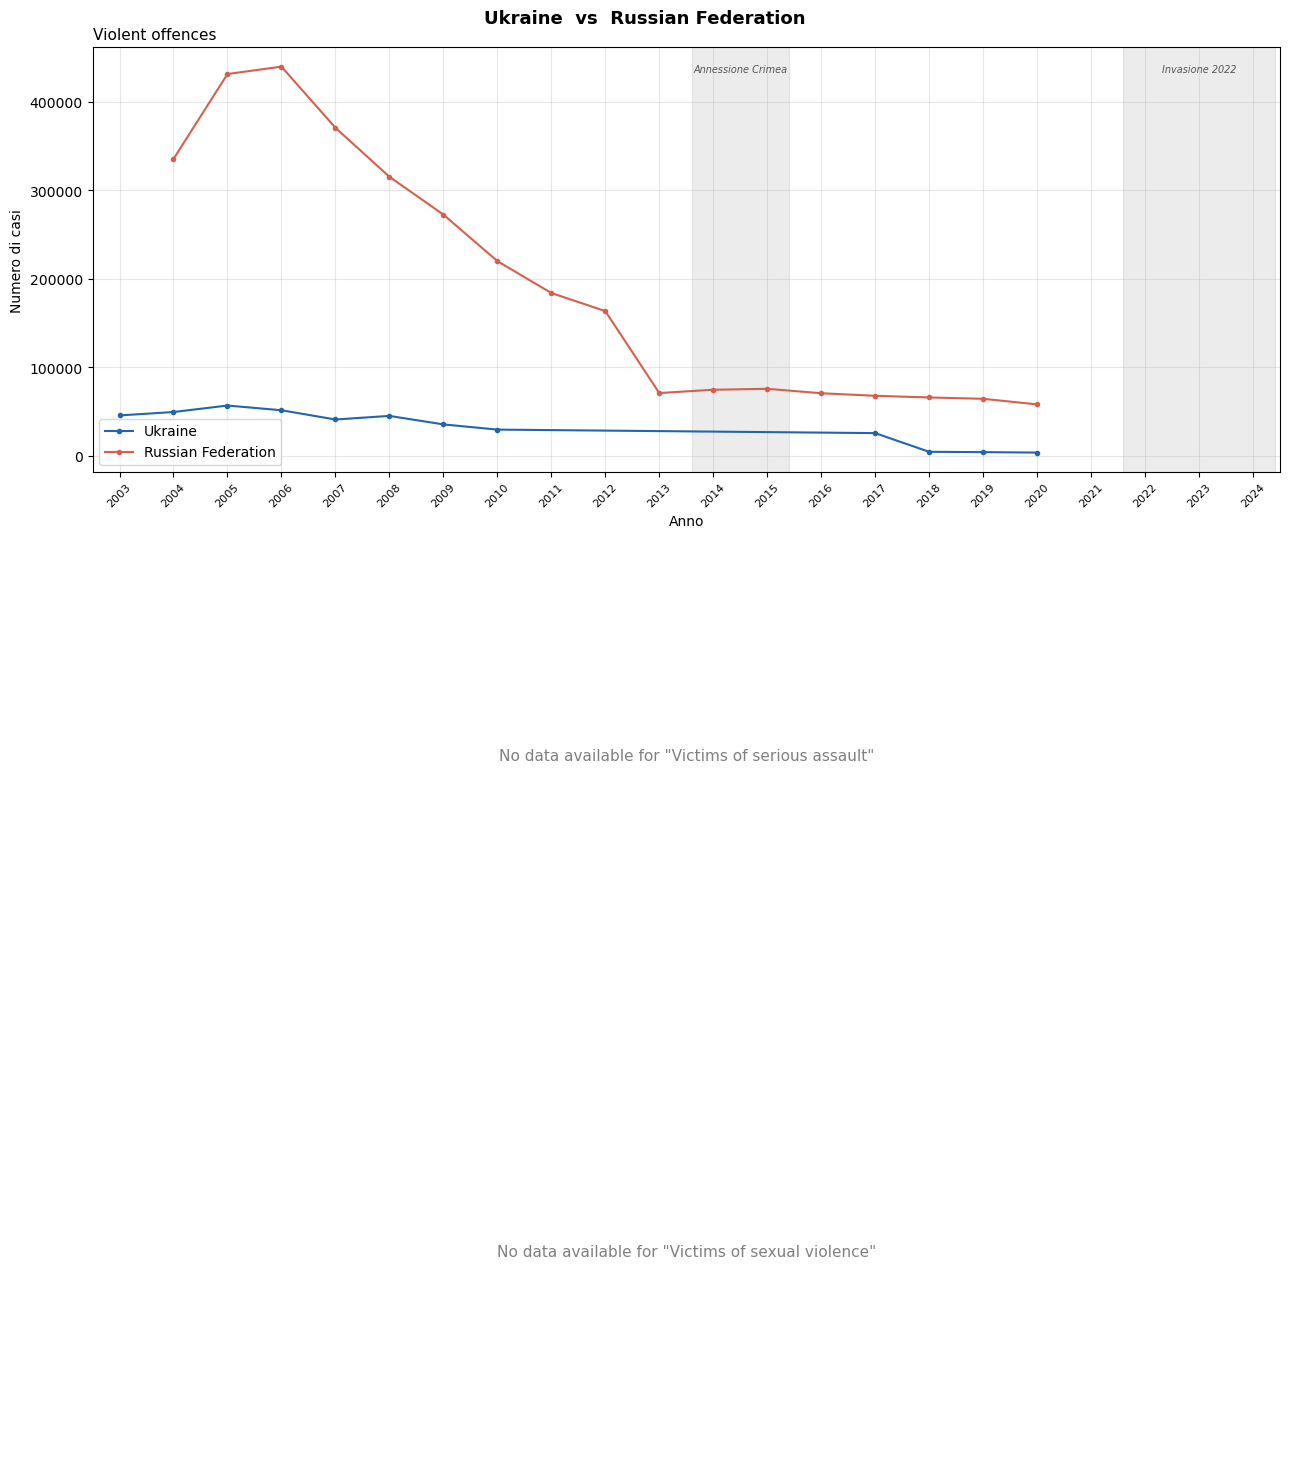

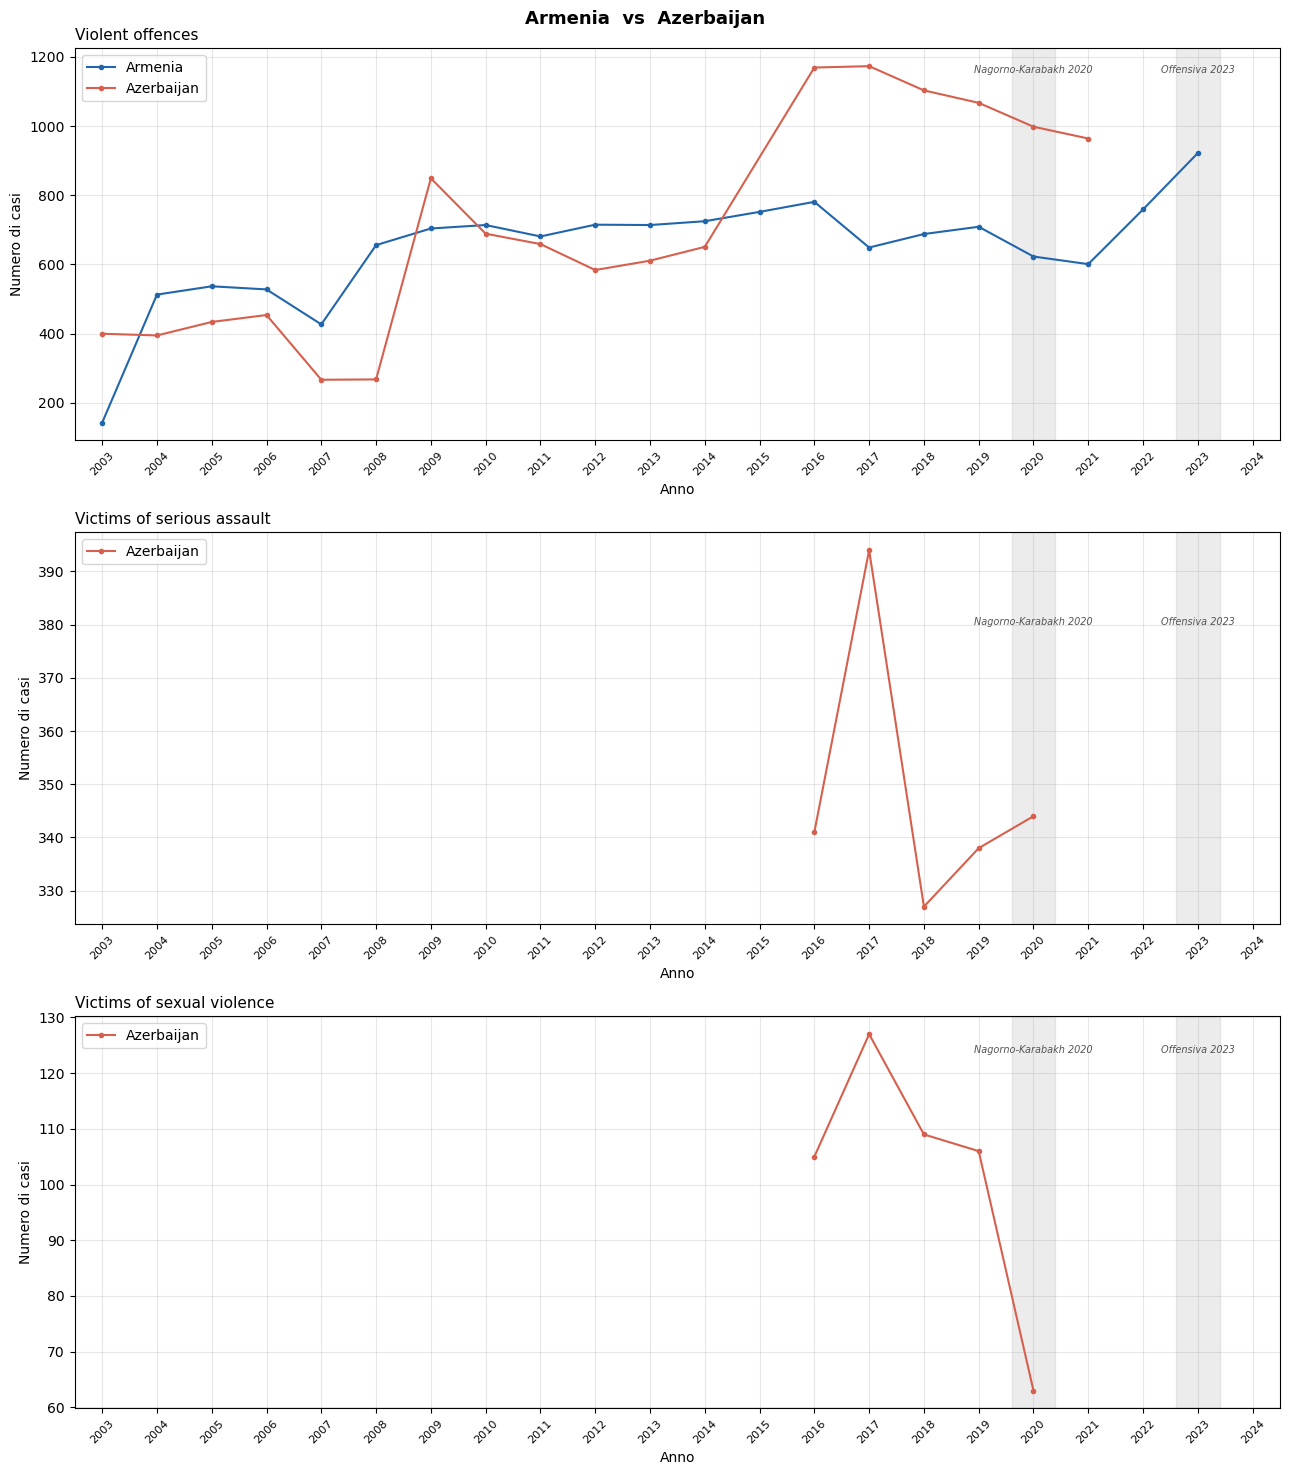

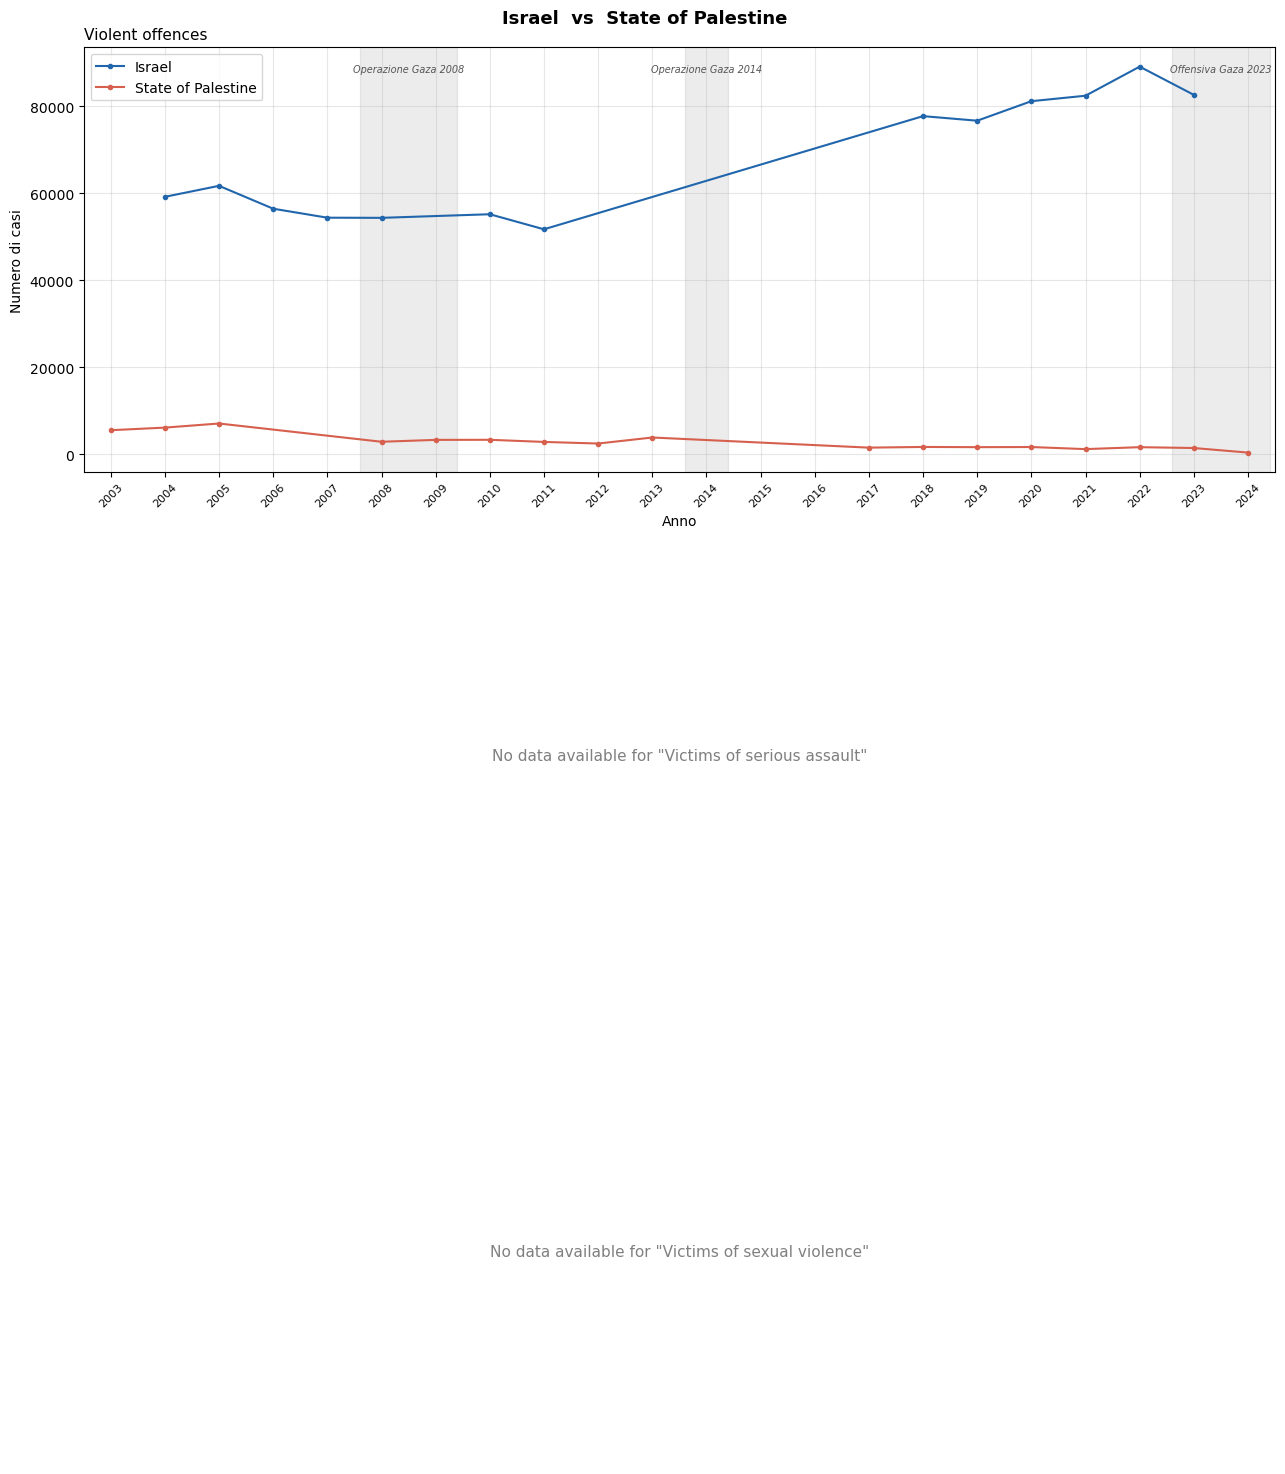

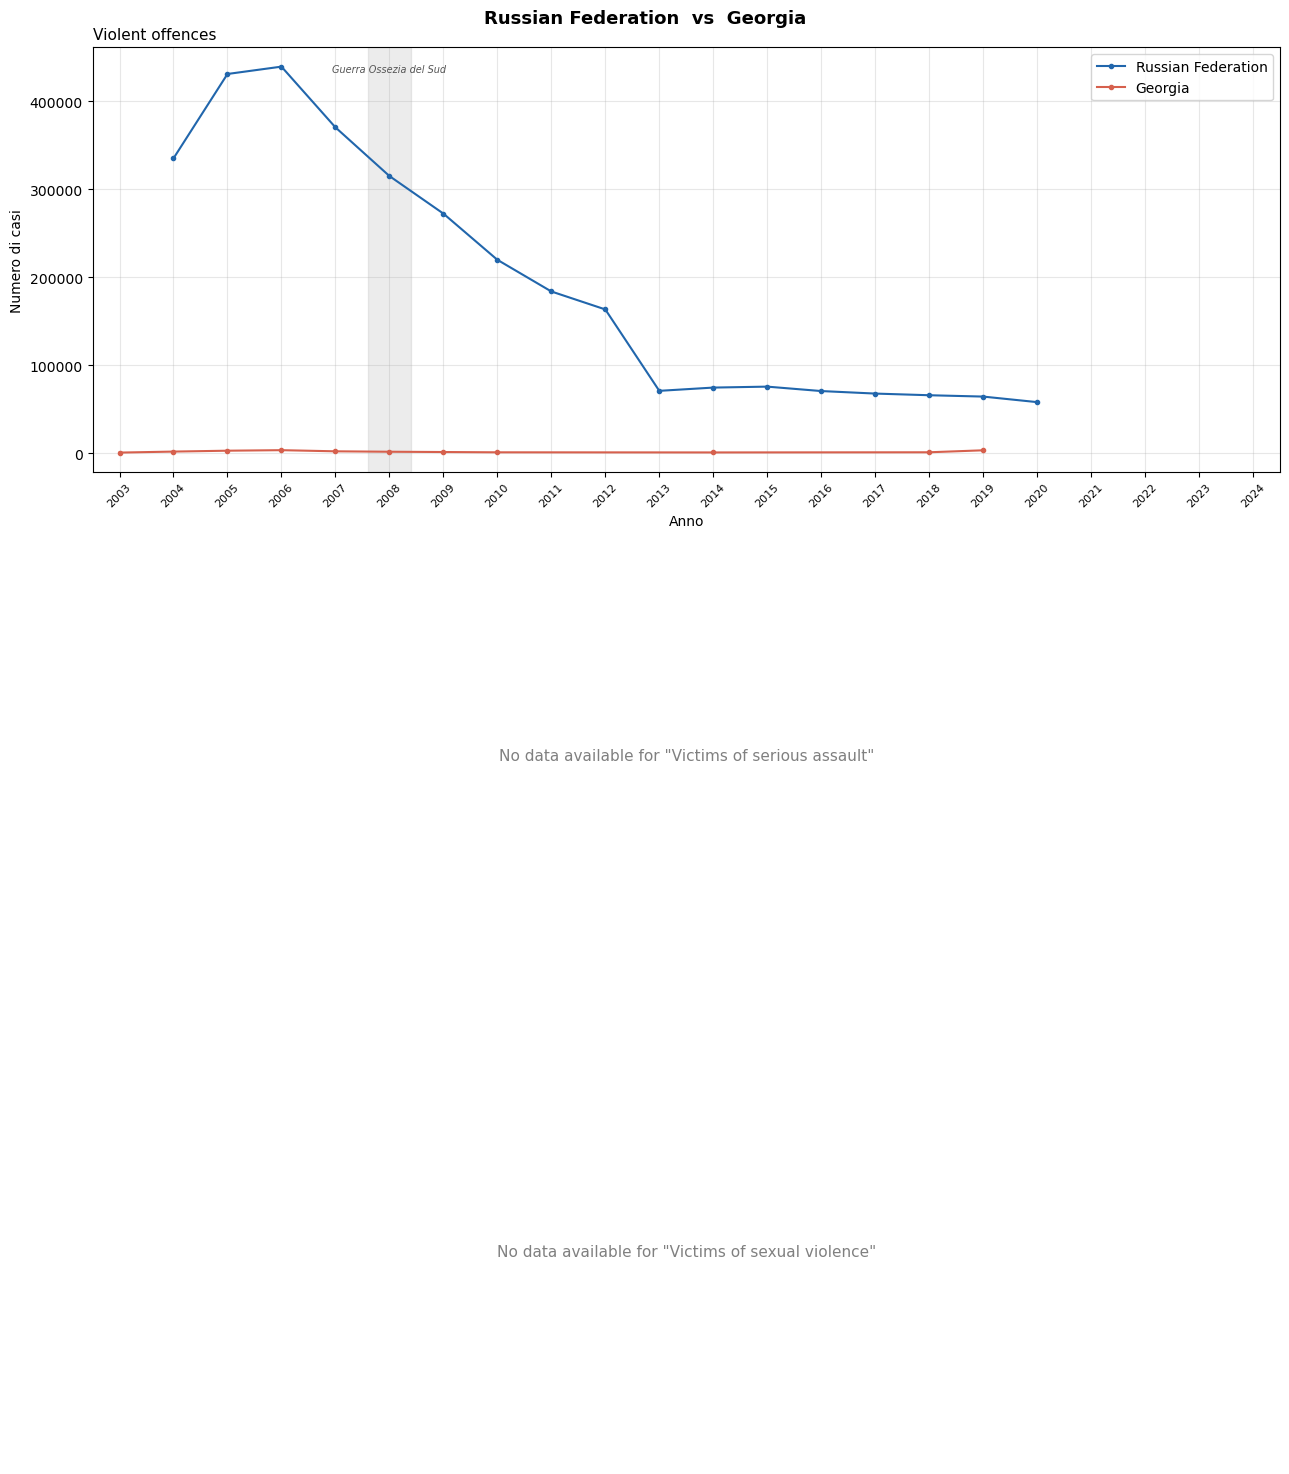

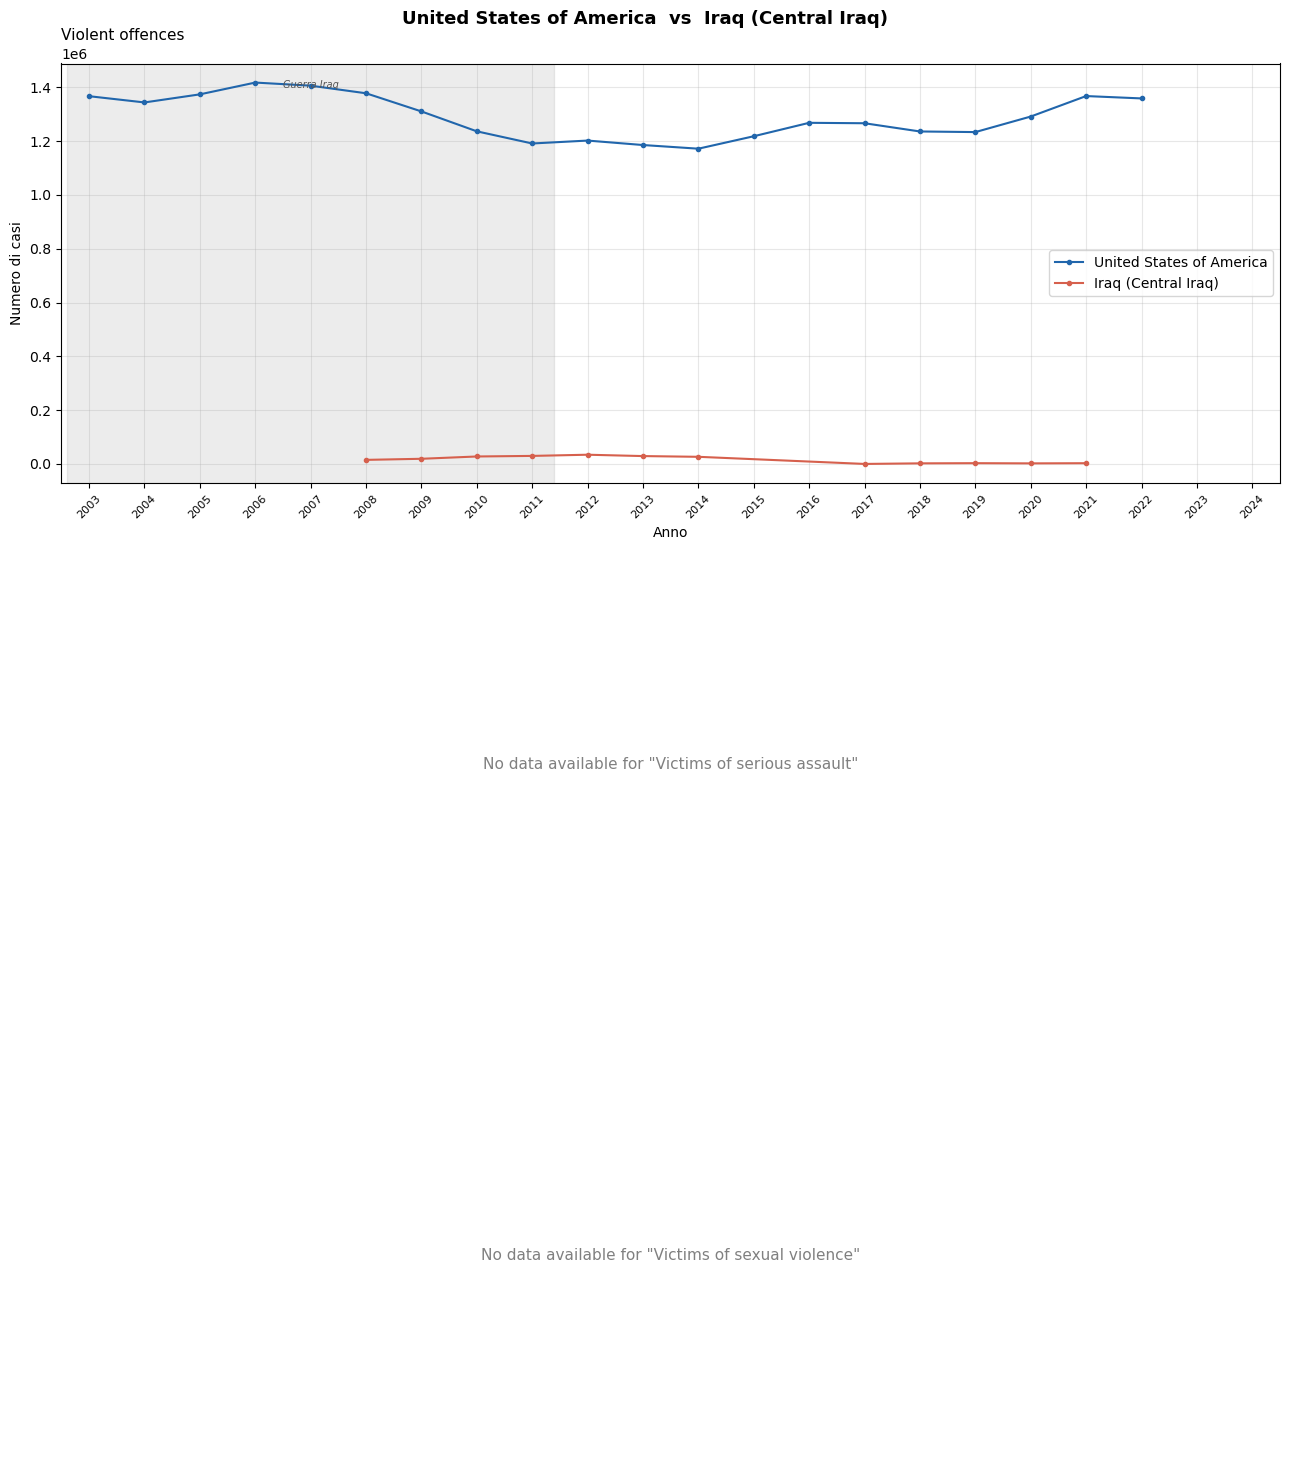

In [7]:
# grafico per coppia paesi in conflitto
seen = set()
for c1, c2, *_ in WARS:
    pair = frozenset([c1, c2])
    if pair not in seen:
        seen.add(pair)
        plot_conflict(data, c1, c2)